# Diffusion kernel на графе: задание

Рассмотрим граф из трёх вершин
$$
V=\{1,2,3\},
\qquad
1\text{ --- }2\text{ --- }3,
$$
где все рёбра имеют вес $1$.

Обозначим через $W$ матрицу весов, через $D$ — матрицу степеней,
через
$$
L=D-W
$$
— графовый лапласиан, а через
$$
K_t=e^{-tL}, \qquad t\ge 0,
$$
— диффузионное ядро.


## Часть I. Теория

### 1. Диффузионное ядро

1. Выписать матрицы $W$, $D$ и $L$.
2. Найти собственные значения и ортонормированный базис собственных векторов матрицы $L$.
3. Получить спектральное разложение
   $$
   L=\sum_{r=1}^3 \lambda_r u_r u_r^\top.
   $$
4. Вычислить
   $$
   K_t=e^{-tL}
   $$
   через спектральную теорему.
5. Найти предел
   $$
   \lim_{t\to\infty} K_t f
   $$
   для произвольного сигнала $f\in\mathbb R^3$.

### 2. Гребневая регрессия с диффузионным ядром

Рассмотрим задачу kernel ridge regression на множестве вершин $V$ с ядром $K_t$:
$$
\frac{1}{3}\|y-K_t\alpha\|_2^2+\lambda\,\alpha^\top K_t\alpha \to \min_{\alpha\in\mathbb R^3},
\qquad \lambda>0.
$$

1. Вывести формулу решения
   $$
   \hat\alpha=(K_t+3\lambda I)^{-1}y.
   $$
2. Выписать ответ для
   $$
   y=(1,0,-1)^\top.
   $$
3. Найти предсказанный сигнал
   $$
   \hat y=K_t\hat\alpha.
   $$
4. Исследовать поведение решения при $t\to 0$, $t\to\infty$ и $\lambda\to 0$.


# Решение: Диффузионное ядро и Kernel Ridge Regression на графе

## Часть I. Теория: Диффузионное ядро

### 1. Матрицы $W$, $D$ и $L$

Граф имеет цепочечную структуру $1-2-3$ с единичными весами рёбер.

**Матрица весов $W$:**
$$
W = \begin{pmatrix}
0 & 1 & 0 \\
1 & 0 & 1 \\
0 & 1 & 0
\end{pmatrix}
$$

**Матрица степеней $D$:**
$$
D = \begin{pmatrix}
1 & 0 & 0 \\
0 & 2 & 0 \\
0 & 0 & 1
\end{pmatrix}
$$

**Графовый лапласиан $L = D - W$:**
$$
L = \begin{pmatrix}
1 & -1 & 0 \\
-1 & 2 & -1 \\
0 & -1 & 1
\end{pmatrix}
$$

### 2. Собственные значения и ортонормированный базис собственных векторов $L$

Характеристический многочлен:
$$
\det(L - \lambda I) = -λ^3+4*λ^2-3*λ
=
-λ*(λ^2-4*λ+3)
=
-λ*(λ-1)*(λ-3)
=
0
$$

**Собственные значения:**
$$
\lambda_1 = 0, \qquad \lambda_2 = 1, \qquad \lambda_3 = 3
$$

**Ортонормированные собственные векторы:**
$$
u_1 = \frac{1}{\sqrt{3}}\begin{pmatrix} 1 \\ 1 \\ 1 \end{pmatrix}, \quad
u_2 = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 \\ 0 \\ -1 \end{pmatrix}, \quad
u_3 = \frac{1}{\sqrt{6}}\begin{pmatrix} 1 \\ -2 \\ 1 \end{pmatrix}
$$

### 3. Спектральное разложение $L$

$$
L = \sum_{r=1}^3 \lambda_r u_r u_r^\top = 0 \cdot u_1 u_1^\top + 1 \cdot u_2 u_2^\top + 3 \cdot u_3 u_3^\top
$$

### 4. Вычисление $K_t = e^{-tL}$ через спектральную теорему

$$
K_t = e^{-tL} = \sum_{r=1}^3 e^{-t\lambda_r} u_r u_r^\top = u_1 u_1^\top + e^{-t} u_2 u_2^\top + e^{-3t} u_3 u_3^\top
$$

### 5. Предел $\lim_{t\to\infty} K_t f$

При $t \to \infty$: $e^{-t} \to 0$, $e^{-3t} \to 0$, следовательно:

$$
\lim_{t\to\infty} K_t = u_1 u_1^\top = \frac{1}{3}\mathbf{1}\mathbf{1}^\top
$$

Для произвольного сигнала $f = (f_1, f_2, f_3)^\top$:

$$
\lim_{t\to\infty} K_t f = \frac{f_1+f_2+f_3}{3} \begin{pmatrix} 1 \\ 1 \\ 1 \end{pmatrix}
$$

## Часть II. Гребневая регрессия с диффузионным ядром

### 1. Вывод формулы решения

Задача минимизации:
$$
J(\alpha) = \frac{1}{3}\|y - K_t \alpha\|_2^2 + \lambda \, \alpha^\top K_t \alpha \to \min_{\alpha \in \mathbb{R}^3}
$$

Градиент:
$$
\nabla_\alpha J(\alpha) = \frac{1}{3}(-2K_t y + 2K_t^2 \alpha) + 2\lambda K_t \alpha = 0
$$

После упрощения:
$$
K_t(K_t + 3\lambda I)\alpha = K_t y
$$

Так как $K_t$ обратима:
$$
\boxed{\hat{\alpha} = (K_t + 3\lambda I)^{-1} y}
$$

### 2. Решение для $y = (1, 0, -1)^\top$

Заметим, что $y = \sqrt{2} \, u_2$. Тогда:

$$
\hat{\alpha} = \frac{1}{e^{-t} + 3\lambda} \begin{pmatrix} 1 \\ 0 \\ -1 \end{pmatrix}
$$

### 3. Предсказанный сигнал $\hat{y} = K_t \hat{\alpha}$

$$
\hat{y} = K_t \hat{\alpha} = \frac{e^{-t}}{e^{-t} + 3\lambda} \begin{pmatrix} 1 \\ 0 \\ -1 \end{pmatrix} = \frac{1}{1 + 3\lambda e^{t}} \begin{pmatrix} 1 \\ 0 \\ -1 \end{pmatrix}
$$

### 4. Исследование поведения решения

**При $t \to 0$:**
$$
\hat{y} \to \frac{1}{1 + 3\lambda} y
$$

**При $t \to \infty$:**
$$
\hat{y} \to 0
$$

**При $\lambda \to 0$:**
$$
\hat{y} \to y
$$

## Часть II. Практика

1. Реализовать матрицы $W$, $D$, $L$ в Python.
2. Численно найти спектр лапласиана.
3. Вычислить $K_t$ двумя способами:
   - через `scipy.linalg.expm`,
   - через спектральное разложение.
4. Проверить совпадение результатов.
5. Для сигнала
   $$
   f=(1,-2,3)^\top
   $$
   визуализировать зависимость $K_t f$ от $t$.
6. Найти предел $K_t f$ при больших $t$ численно и сравнить с теоретическим ответом.
7. Реализовать kernel ridge regression с ядром $K_t$ для
   $$
   y=(1,0,-1)^\top
   $$
   и исследовать влияние $t$ и $\lambda$ на предсказанный сигнал.


### Вспомогательный файл Laplacian.pdf
### Во избежание путаницы, прошу назвать файл HW6_фамилия.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

np.set_printoptions(precision=4, suppress=True)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# 1. Построение матриц
W = np.array([[0., 1., 0.],
              [1., 0., 1.],
              [0., 1., 0.]])
D = np.diag(W.sum(axis=1))
L = D - W

print("W =\n", W)
print("D =\n", D)
print("L =\n", L)

# 2. Численное нахождение спектра

eigenvalues, eigenvectors = np.linalg.eigh(L) # eigh возвращает отсортированные по возрастанию собственные значения

print("\nСобственные значения:", eigenvalues)
print("Собственные векторы (по столбцам):\n", eigenvectors)

W =
 [[0. 1. 0.]
 [1. 0. 1.]
 [0. 1. 0.]]
D =
 [[1. 0. 0.]
 [0. 2. 0.]
 [0. 0. 1.]]
L =
 [[ 1. -1.  0.]
 [-1.  2. -1.]
 [ 0. -1.  1.]]

Собственные значения: [0. 1. 3.]
Собственные векторы (по столбцам):
 [[-0.5774 -0.7071  0.4082]
 [-0.5774  0.     -0.8165]
 [-0.5774  0.7071  0.4082]]


In [4]:
def Kt_spectral(t, lambdas, U):
    """Вычисление через спектральное разложение: K_t = U diag(e^{-tλ}) U^T"""
    return U @ np.diag(np.exp(-t * lambdas)) @ U.T

def Kt_expm(t, L):
    """Вычисление через матричную экспоненту"""
    return expm(-t * L)

t_test = 1.5
Kt_sp = Kt_spectral(t_test, eigenvalues, eigenvectors)
Kt_ex = Kt_expm(t_test, L)

# 4. Проверка совпадения
diff = np.max(np.abs(Kt_sp - Kt_ex))
print(f"Максимальная поэлементная разница: {diff:.2e}")
assert diff < 1e-10, "Методы дают разные результаты!"
print("Методы совпадают.")

Максимальная поэлементная разница: 3.33e-16
Методы совпадают.


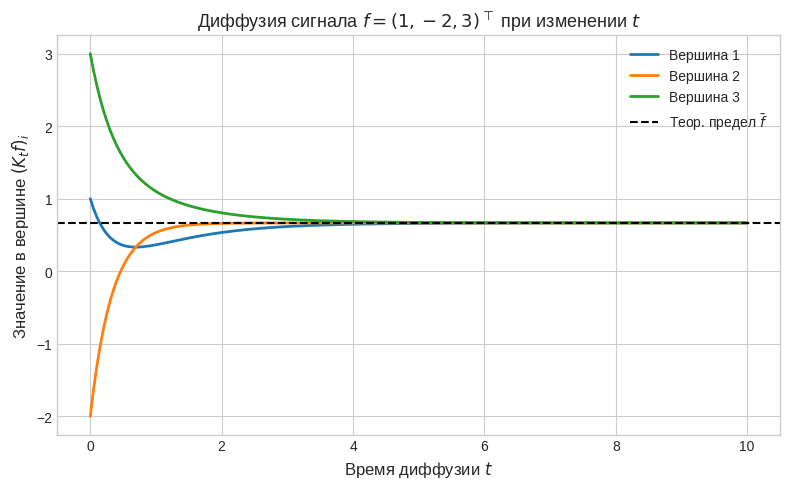

In [5]:
f = np.array([1., -2., 3.])
t_range = np.linspace(0, 10, 200)
Kt_f_traj = np.zeros((len(t_range), 3))

for i, t in enumerate(t_range):
    Kt = Kt_spectral(t, eigenvalues, eigenvectors)
    Kt_f_traj[i] = Kt @ f

plt.figure(figsize=(8, 5))
plt.plot(t_range, Kt_f_traj[:, 0], label='Вершина 1', linewidth=2)
plt.plot(t_range, Kt_f_traj[:, 1], label='Вершина 2', linewidth=2)
plt.plot(t_range, Kt_f_traj[:, 2], label='Вершина 3', linewidth=2)
plt.axhline(y=np.mean(f), color='black', linestyle='--', linewidth=1.5, label=r'Теор. предел $\bar{f}$')
plt.title(r'Диффузия сигнала $f=(1,-2,3)^\top$ при изменении $t$', fontsize=13)
plt.xlabel('Время диффузии $t$', fontsize=12)
plt.ylabel('Значение в вершине $(K_t f)_i$', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
t_large = 15.0
Kt_large = Kt_spectral(t_large, eigenvalues, eigenvectors)
limit_num = Kt_large @ f
limit_theo = np.full(3, np.mean(f))

print(f"Численный предел при t={t_large}: {limit_num}")
print(f"Теоретический предел (среднее): {limit_theo}")
print(f"Норма ошибки: {np.linalg.norm(limit_num - limit_theo):.2e}")

Численный предел при t=15.0: [0.6667 0.6667 0.6667]
Теоретический предел (среднее): [0.6667 0.6667 0.6667]
Норма ошибки: 4.33e-07


<>:25: SyntaxWarning: invalid escape sequence '\h'
<>:27: SyntaxWarning: invalid escape sequence '\h'
<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:43: SyntaxWarning: invalid escape sequence '\h'
<>:25: SyntaxWarning: invalid escape sequence '\h'
<>:27: SyntaxWarning: invalid escape sequence '\h'
<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:43: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1894/1253882094.py:25: SyntaxWarning: invalid escape sequence '\h'
  plt.title('Влияние $t$ на предсказание $\hat{y}_1$', fontsize=12)
/tmp/ipykernel_1894/1253882094.py:27: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('$\hat{y}_1$')
/tmp/ipykernel_1894/1253882094.py:41: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Влияние $\lambda$ на предсказание $\hat{y}_1$', fontsize=12)
/tmp/ipykernel_1894/1253882094.py:42: SyntaxWarning: invalid escape sequen

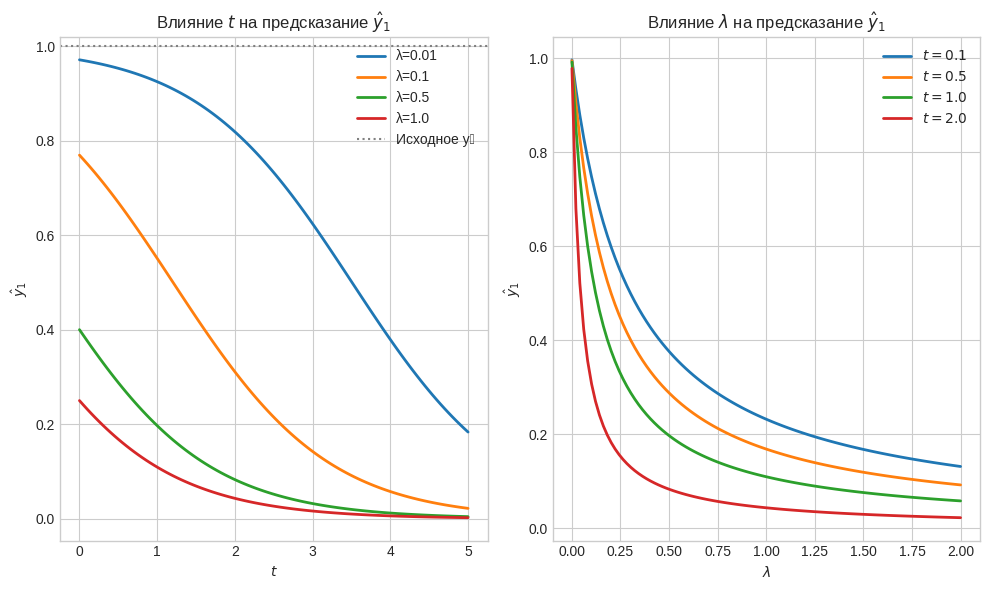

In [8]:
y = np.array([1., 0., -1.])

def solve_krr(t, lam, lambdas, U, y):
    """Решение KRR: α = (K_t + 3λI)^{-1}y, ŷ = K_t α"""
    Kt = Kt_spectral(t, lambdas, U)
    alpha = np.linalg.solve(Kt + 3 * lam * np.eye(3), y)
    y_pred = Kt @ alpha
    return y_pred

# Исследуем влияние t и λ
t_grid = np.linspace(0, 5, 100)
lambda_values = [0.01, 0.1, 0.5, 1.0]

plt.figure(figsize=(10, 6))

# График 1: Зависимость первой компоненты ŷ₁ от t при разных λ
plt.subplot(1, 2, 1)
for lam in lambda_values:
    y1_vals = []
    for t in t_grid:
        y_pred = solve_krr(t, lam, eigenvalues, eigenvectors, y)
        y1_vals.append(y_pred[0])
    plt.plot(t_grid, y1_vals, label=f'λ={lam}', linewidth=2)
plt.axhline(1.0, color='gray', linestyle=':', label='Исходное y₁')
plt.title('Влияние $t$ на предсказание $\hat{y}_1$', fontsize=12)
plt.xlabel('$t$')
plt.ylabel('$\hat{y}_1$')
plt.legend()

# График 2: Зависимость ŷ₁ от λ при разных t
t_points = [0.1, 0.5, 1.0, 2.0]
lam_grid = np.linspace(0.001, 2.0, 100)

plt.subplot(1, 2, 2)
for t_pt in t_points:
    y1_vs_lam = []
    for lam in lam_grid:
        y_pred = solve_krr(t_pt, lam, eigenvalues, eigenvectors, y)
        y1_vs_lam.append(y_pred[0])
    plt.plot(lam_grid, y1_vs_lam, label=f'$t={t_pt}$', linewidth=2)
plt.title('Влияние $\lambda$ на предсказание $\hat{y}_1$', fontsize=12)
plt.xlabel('$\lambda$')
plt.ylabel('$\hat{y}_1$')
plt.legend()

plt.tight_layout()
plt.show()